In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
spe_data = pd.read_excel("data/species_535.xlsx", index_col=0)
food_data_spear = pd.read_csv('data/Summarized_Food_Categories_Only.csv', index_col=0)
participants_data = pd.read_csv('data/demo_535.csv', index_col=0)

In [8]:
common_indices = spe_data.index.intersection(food_data_spear.index)
spe_data = spe_data.loc[common_indices]
food_data_spear = food_data_spear.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [9]:
# Convert data to numeric and handle non-numeric entries
spe_data = spe_data.apply(pd.to_numeric, errors='coerce')
food_data_spear = food_data_spear.apply(pd.to_numeric, errors='coerce')
participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')

In [10]:
def adjust_for_covariates(data, covariates):
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid
    return adjusted_data



# Adjust microbiome and diet data
adjusted_spe_data = adjust_for_covariates(spe_data, participants_data[['BMI', 'FREG8_Age']])
adjusted_food_spear = adjust_for_covariates(food_data_spear, participants_data[['BMI', 'FREG8_Age']])


In [11]:
correlations_spe = pd.DataFrame(index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)
p_values_spe = pd.DataFrame(index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_spe = correlations_spe.astype(float)  # Convert to float
p_values_spe = p_values_spe.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_spe.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value

In [12]:
for microbe in adjusted_spe_data.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_spe_data[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_spe_data[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_spe.loc[microbe, nutrient] = corr
            p_values_spe.loc[microbe, nutrient] = pval
        else:
            correlations_spe.loc[microbe, nutrient] = np.nan
            p_values_spe.loc[microbe, nutrient] = np.nan

/Users/qd/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/stats.py:4264: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


In [25]:
p_flat = p_values_spe.values.flatten()
reject, corrected_pvals_spe, _, _ = multipletests(p_flat, alpha=0.2, method='fdr_bh')
significant_matrix_spe = pd.DataFrame(reject.reshape(p_values_spe.shape), index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_spe.sum(axis=1)

# Filter species with at least 10 significant correlations
significant_species = true_counts >= 11
filtered_species_spe = correlations_spe.loc[significant_species.index[significant_species]]


In [26]:
filtered_species_spe

,Fish,Crustacean,Mollusk,Seafood_dishes,Poultry,Red_meat,Meat_dishes,Processed_meat,Dairy,Cruciferous_vegetables,Legumes,Mushroom,Fruits,Wholegrain,Chapati,Noodle_dishes,Deep_fried,Coffee,Tea
Rhizobium sp. BT-226,0.048007,0.192958,0.294953,0.072774,0.096083,0.101592,0.090479,0.139657,-0.006627,-0.042301,0.006286,-0.137050,-0.099920,-0.015373,-0.119941,0.027296,0.128126,0.098710,-0.074975
Haemophilus haemolyticus,-0.017772,0.006027,0.113041,0.004763,0.095028,0.089939,0.097704,0.160511,0.118140,0.040832,0.108919,0.023657,0.114060,0.013590,0.582764,0.070382,-0.021749,0.113058,0.162211
Paralcaligenes sp. KSB-10,-0.081851,-0.139950,-0.252169,-0.094578,-0.092201,-0.080030,-0.092118,-0.137931,-0.019556,-0.035829,-0.129179,0.018980,-0.045715,-0.065548,-0.134817,-0.004829,-0.070009,-0.095648,0.013903
Chromobacterium sp. Rain0013,0.054400,0.221082,0.349275,0.064888,0.086620,0.082062,0.082508,0.172579,0.000069,-0.028368,0.062608,-0.092384,-0.030532,0.007338,-0.113391,-0.040591,0.151625,0.161006,-0.085053
Mariprofundus aestuarium,-0.028570,-0.172703,-0.321041,-0.030519,-0.083444,-0.083256,-0.084277,-0.129298,0.027250,0.043694,-0.026215,0.087813,0.034929,0.005204,0.168429,0.020469,-0.148691,-0.125606,0.128741
Rothia kristinae,-0.062874,-0.093207,-0.207859,-0.066138,-0.156591,-0.097599,-0.121967,-0.152090,0.011356,-0.104170,-0.088410,-0.043941,-0.081587,0.011313,-0.300614,-0.014598,-0.029576,-0.106931,-0.085426
Streptomyces pratensis,-0.061536,-0.194334,-0.346269,-0.060404,-0.104454,-0.082054,-0.081830,-0.165357,0.041768,0.014512,-0.048334,0.101974,0.015261,0.040531,0.140108,0.003356,-0.159133,-0.102289,0.102823
Bifidobacterium angulatum,-0.110055,-0.112540,-0.186032,-0.093251,-0.140141,-0.133882,-0.144491,-0.042455,0.134320,-0.017604,0.018092,-0.021494,0.093778,0.029400,0.210967,-0.124044,0.010512,-0.025032,0.145499
Streptococcus sobrinus,-0.031780,-0.036330,-0.080999,-0.056167,-0.114166,-0.092035,-0.121899,-0.158317,-0.010365,-0.092751,-0.043349,-0.074333,-0.114386,0.093100,-0.632049,-0.099788,0.018833,-0.113780,-0.191473
Leuconostoc kimchii,0.069937,0.194904,0.255439,0.085466,0.082975,0.102035,0.089448,0.178371,0.063408,-0.004880,0.082974,0.019553,0.014816,-0.029522,0.239948,0.089806,0.086761,0.164308,0.123498


<Figure size 1440x1440 with 0 Axes>

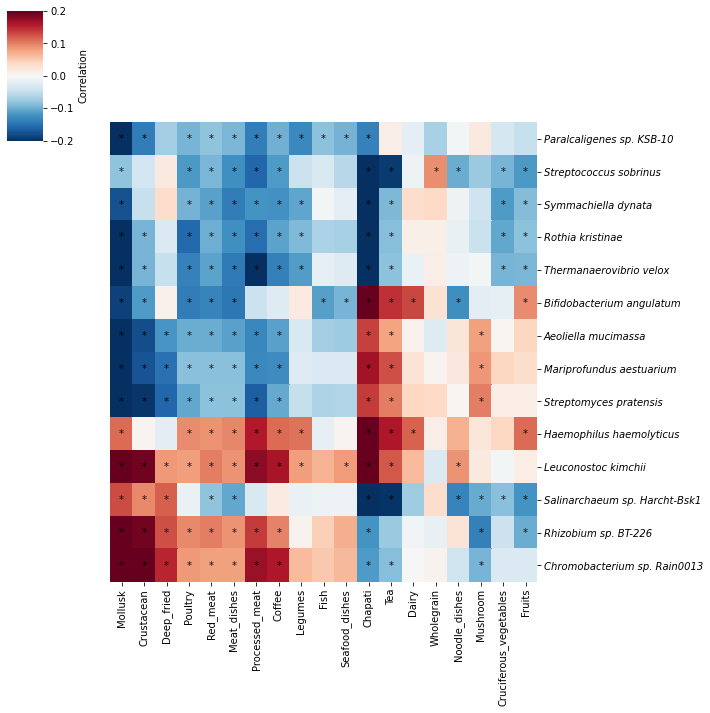

In [27]:
filtered_significance_matrix_spe = significant_matrix_spe.loc[filtered_species_spe.index, filtered_species_spe.columns]
clipped_correlations_spe = np.clip(filtered_species_spe, -0.2, 0.2)


plt.figure(figsize=(20, 20))
ax = sns.clustermap(clipped_correlations_spe, cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=True)

ax.ax_row_dendrogram.set_visible(False)
ax.ax_col_dendrogram.set_visible(False)

row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

for (i, j), significant in np.ndenumerate(filtered_significance_matrix_spe):
    if significant:
        # Find the new position in the clustered heatmap
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]

# Set the y-axis labels to italicized text
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic'})
plt.rc('font', size=15)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=15)

plt.show()

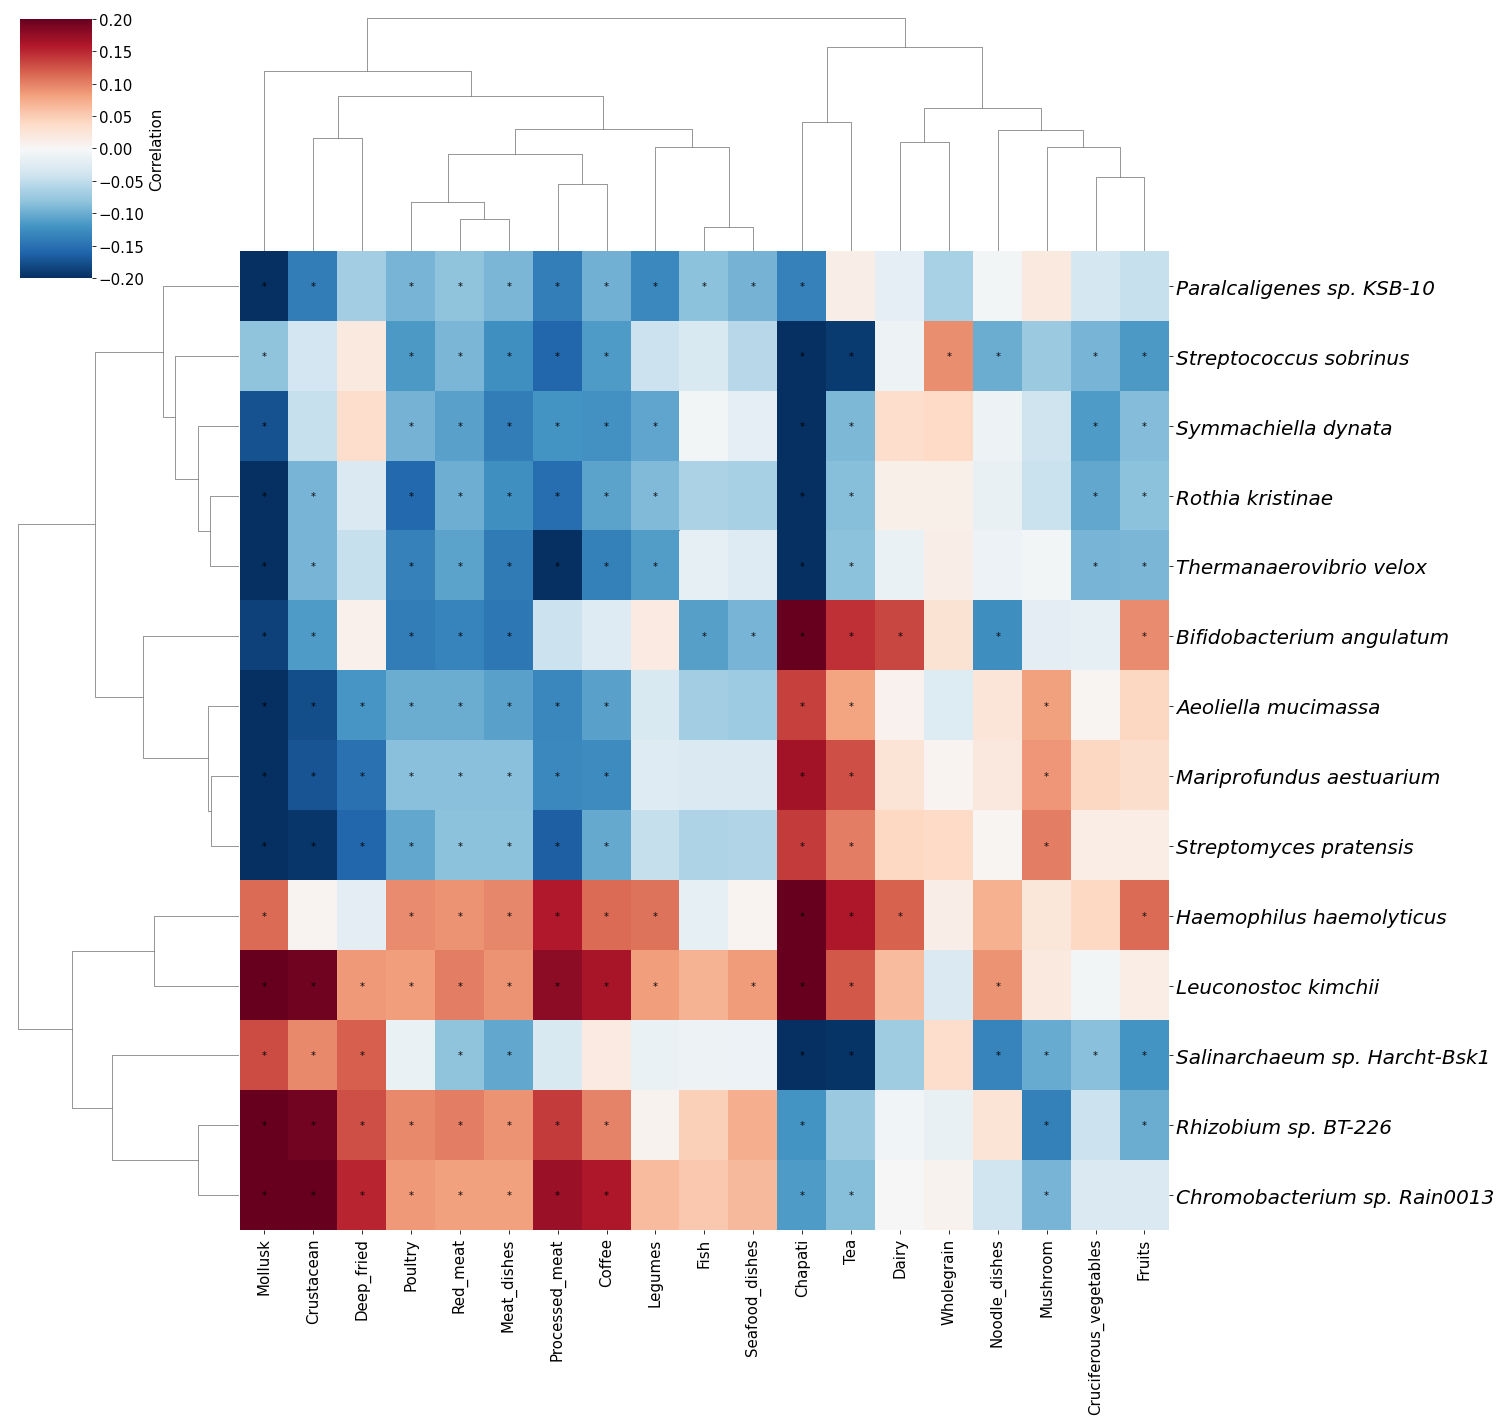

In [37]:
# Assuming filtered_species_scfa, significant_matrix_scfa are defined as per your context
# Clipping values
clipped_correlations_spe = np.clip(filtered_species_spe, -0.2, 0.2)

# Setup figure settings beforehand
plt.rc('font', size=15)  # Adjusting global font size
plt.rc('axes', labelsize=15, titlesize=15)  # Adjusting label and title sizes

# Create clustermap
ax = sns.clustermap(
    clipped_correlations_spe,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={'label': 'Correlation'},
    vmin=-0.2,
    vmax=0.2,
    row_cluster=True,
    col_cluster=True,
    figsize=(20, 20)  # Adjust size directly here if needed
)

# Making dendrograms visible to check the layout
ax.ax_row_dendrogram.set_visible(True)
ax.ax_col_dendrogram.set_visible(True)

# Get the order of rows and columns after clustering
row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

# Highlight significant cells
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_spe):
    if significant:
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

# Adjust y-tick labels
y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic', 'fontsize': 20})
#plt.savefig('figure/food_all_spe_heatmap.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
## nutrient

In [29]:
food_row_order = ax.dendrogram_row.reordered_ind

In [30]:
food_row_order

[2, 8, 11, 5, 12, 7, 10, 4, 6, 1, 9, 13, 0, 3]

In [31]:
spe_data = pd.read_excel("data/species_535.xlsx", index_col=0)
food_data_spear = pd.read_csv('data/nutrition_535.csv', index_col=0)
participants_data = pd.read_csv('data/demo_535.csv', index_col=0)

In [32]:
common_indices = spe_data.index.intersection(food_data_spear.index)
spe_data = spe_data.loc[common_indices]
food_data_spear = food_data_spear.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [33]:
# Convert data to numeric and handle non-numeric entries
spe_data = spe_data.apply(pd.to_numeric, errors='coerce')
food_data_spear = food_data_spear.apply(pd.to_numeric, errors='coerce')
participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')

In [34]:
def adjust_for_covariates(data, covariates):
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid
    return adjusted_data



# Adjust microbiome and diet data
adjusted_spe_data = adjust_for_covariates(spe_data, participants_data[['BMI', 'FREG8_Age']])
adjusted_food_spear = adjust_for_covariates(food_data_spear, participants_data[['BMI', 'FREG8_Age']])


In [35]:
correlations_spe = pd.DataFrame(index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)
p_values_spe = pd.DataFrame(index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_spe = correlations_spe.astype(float)  # Convert to float
p_values_spe = p_values_spe.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_spe.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value

In [36]:
for microbe in adjusted_spe_data.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_spe_data[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_spe_data[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_spe.loc[microbe, nutrient] = corr
            p_values_spe.loc[microbe, nutrient] = pval
        else:
            correlations_spe.loc[microbe, nutrient] = np.nan
            p_values_spe.loc[microbe, nutrient] = np.nan

/Users/qd/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/stats.py:4264: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


In [38]:
p_flat = p_values_spe.values.flatten()
reject, corrected_pvals_spe, _, _ = multipletests(p_flat, alpha=0.2, method='fdr_bh')
significant_matrix_spe = pd.DataFrame(reject.reshape(p_values_spe.shape), index=adjusted_spe_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_spe.sum(axis=1)

# Filter species with at least 10 significant correlations
#significant_species = true_counts >= 0
filtered_species_spe = correlations_spe.loc[significant_species.index[significant_species]]
#significant_species

filtered_species_spe = filtered_species_spe.iloc[food_row_order, :]
filtered_species_spe

,Water,Energy,Protein,Total_fat,Saturated_fatty_acid,MUFA,PUFA,CHO,starch,sugar,...,transfat,Bcarotene,Retinol,Thiamin,Riboflavin,Folate,VitaminB12,Potassium,Magnesium,Zinc
Paralcaligenes sp. KSB-10,0.009340,-0.063861,-0.083996,-0.080430,-0.051835,-0.088363,-0.098490,-0.041975,-0.042057,-0.019809,...,0.194211,-0.084927,-0.014518,-0.068909,-0.050929,-0.068801,0.015597,-0.069865,0.338425,-0.072579
Streptococcus sobrinus,-0.064254,-0.015362,-0.014947,-0.020702,-0.015530,-0.029191,-0.011156,-0.005981,0.005463,-0.020896,...,-0.209454,-0.048307,-0.096158,-0.020630,-0.008509,-0.068400,0.003391,-0.049551,-0.382026,0.008897
Symmachiella dynata,0.210733,0.010361,0.003445,0.010012,0.022642,0.006312,-0.007434,0.002956,-0.004279,0.031647,...,0.170969,-0.064248,0.135166,0.016630,0.039600,-0.024506,0.192593,-0.007375,0.032505,0.008065
Rothia kristinae,0.032505,-0.030538,-0.052679,-0.048111,-0.022969,-0.062521,-0.064230,-0.004529,-0.021014,0.050493,...,0.288134,-0.036466,0.017478,-0.016546,-0.004071,-0.031364,0.011236,-0.045105,0.326341,-0.031964
Thermanaerovibrio velox,0.011775,-0.035471,-0.042270,-0.044173,-0.023570,-0.050587,-0.062752,-0.031214,-0.028955,-0.025754,...,0.279426,-0.114908,0.055315,-0.042042,-0.012305,-0.017385,0.040473,-0.057775,0.319868,-0.025918
Bifidobacterium angulatum,-0.068292,-0.039097,-0.077274,-0.072601,-0.055965,-0.082871,-0.055186,0.003906,-0.034006,0.103365,...,0.180093,-0.016838,-0.151658,0.007823,-0.016162,-0.095572,-0.232881,-0.009976,0.385787,-0.074349
Aeoliella mucimassa,0.140114,-0.033994,-0.051385,-0.047272,-0.022230,-0.064954,-0.046369,-0.021623,-0.040834,0.028567,...,0.534686,-0.019544,0.055192,-0.021353,-0.019096,0.010172,0.072037,-0.020131,0.697594,-0.050334
Mariprofundus aestuarium,0.069803,-0.041997,-0.049660,-0.050861,-0.030941,-0.062948,-0.059810,-0.033511,-0.044701,0.005723,...,0.513324,-0.023091,0.028451,-0.017590,-0.013421,-0.000493,0.032073,-0.017103,0.736680,-0.041599
Streptomyces pratensis,0.120555,-0.043844,-0.043117,-0.063782,-0.048680,-0.074338,-0.065597,-0.033647,-0.040204,-0.001854,...,0.569332,-0.044591,0.051893,0.000458,-0.009893,0.038777,0.043170,-0.030004,0.803832,-0.033458
Haemophilus haemolyticus,0.010280,0.103072,0.081469,0.080863,0.067912,0.074543,0.099771,0.118560,0.113280,0.086404,...,0.091457,0.089215,0.092351,0.134755,0.091956,0.111663,-0.051446,0.110515,0.144106,0.084348


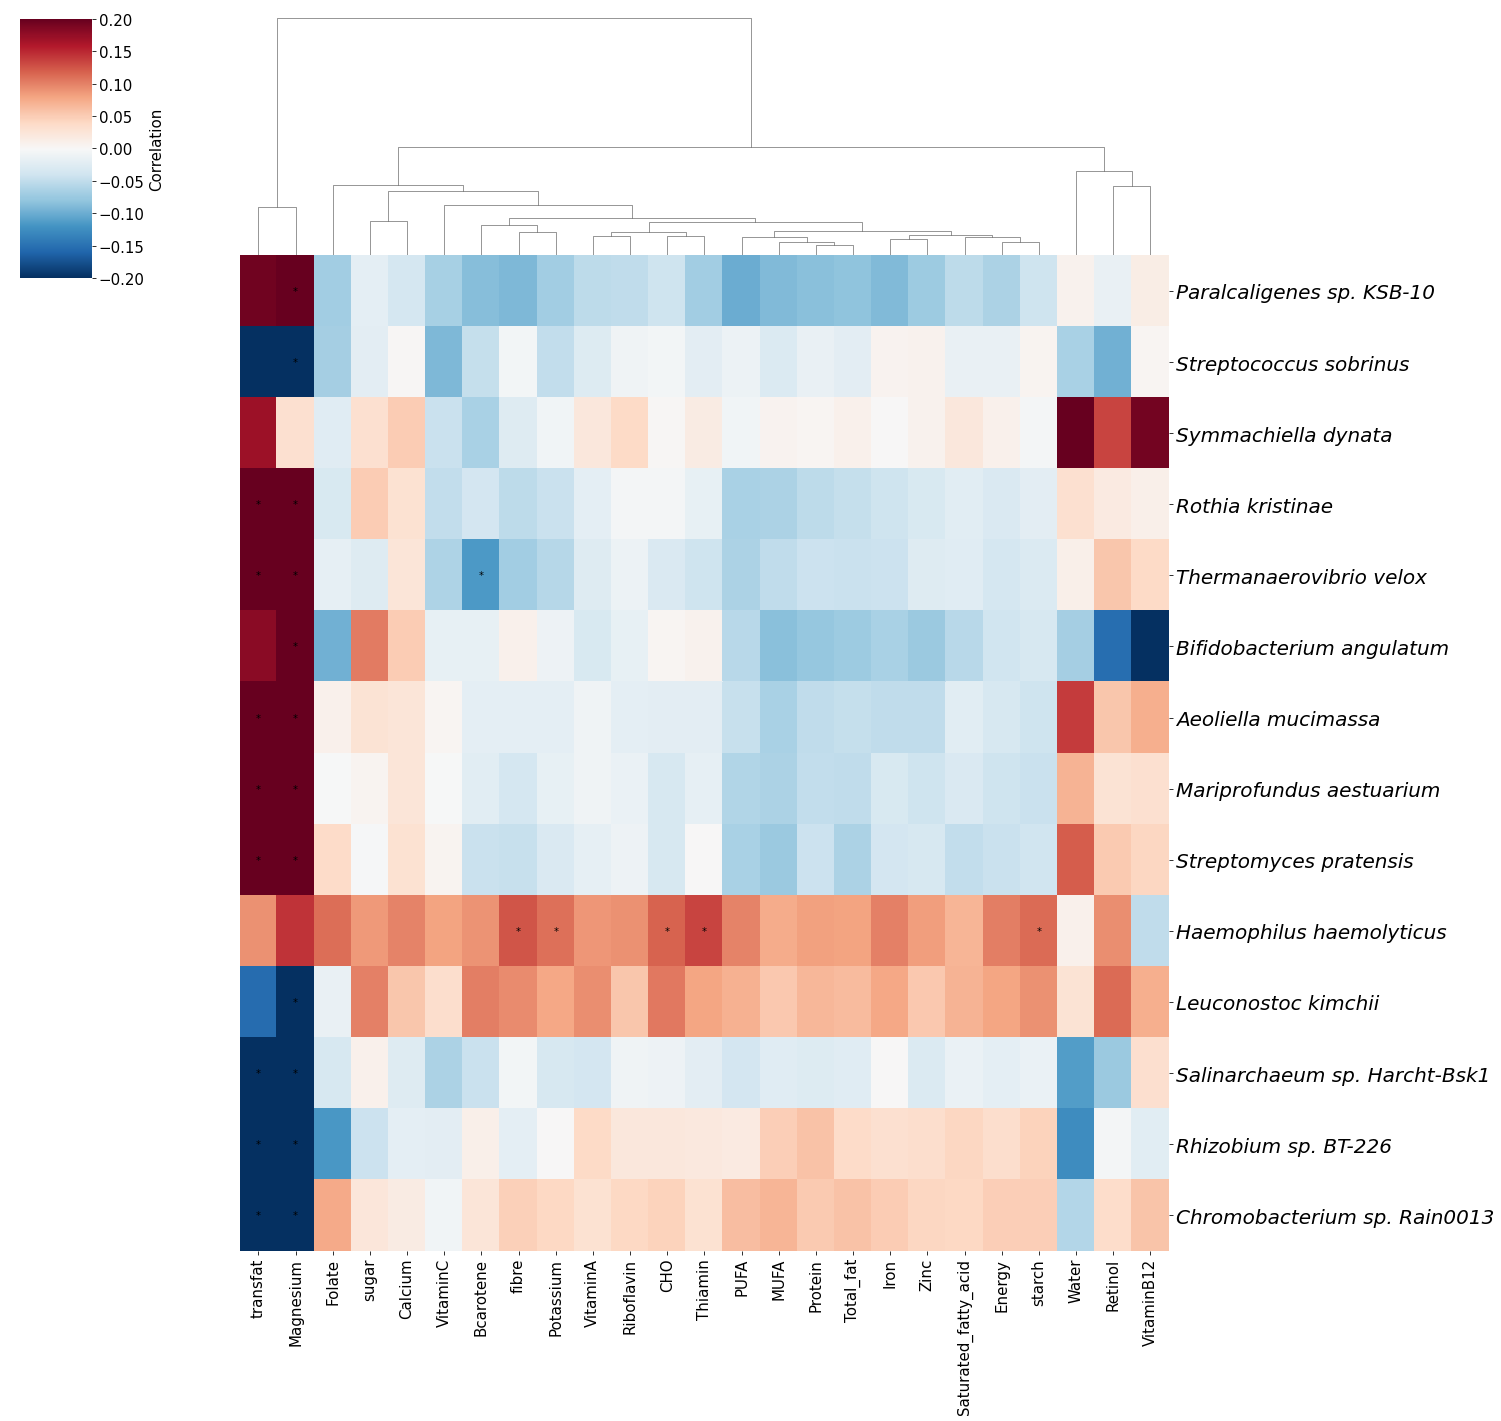

In [40]:
filtered_significance_matrix_spe = significant_matrix_spe.loc[filtered_species_spe.index, filtered_species_spe.columns]


clipped_correlations_spe = np.clip(filtered_species_spe, -0.2, 0.2)

# Setup figure settings beforehand
plt.rc('font', size=15)  # Adjusting global font size
plt.rc('axes', labelsize=15, titlesize=15)  # Adjusting label and title sizes

# Create clustermap with rows in fixed order
ax = sns.clustermap(
    clipped_correlations_spe,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={'label': 'Correlation'},
    vmin=-0.2,
    vmax=0.2,
    row_cluster=False,  # Disable row clustering
    col_cluster=True,   # Enable column clustering if desired
    figsize=(20, 20)    # Adjust size directly here if needed
)

# Since row clustering is disabled, row order is unchanged, retrieve column order
col_order = ax.dendrogram_col.reordered_ind

# Highlight significant cells (adjusted for column clustering only)
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_spe):
    if significant:
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, i + 0.5, '*', ha='center', va='center', color='black', size=10)

# Adjust y-tick labels
y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic', 'fontsize': 20})

#plt.savefig('figure/nutrition_all_spe_heatmap.png', format='png', dpi=300, bbox_inches='tight')
plt.show()